<a href="https://colab.research.google.com/github/Manav716/credit-risk-model/blob/main/Credit_risk_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/german_credit_data.csv')

In [ ]:
df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,Good
1,22,female,2,own,little,moderate,5951,48,radio/TV,Bad
2,49,male,1,own,little,NaN,2096,12,education,Good
3,45,male,2,free,little,little,7882,42,furniture/equipment,Good
4,53,male,2,free,little,little,4870,24,car,Bad


In [ ]:
df.shape

(1000, 10)

In [ ]:
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               1000 non-null   int64 
 1   Sex               1000 non-null   object
 2   Job               1000 non-null   int64 
 3   Housing           1000 non-null   object
 4   Saving accounts   817 non-null    object
 5   Checking account  606 non-null    object
 6   Credit amount     1000 non-null   int64 
 7   Duration          1000 non-null   int64 
 8   Purpose           1000 non-null   object
 9   Risk              1000 non-null   object
dtypes: int64(4), object(6)
memory usage: 78.3+ KB


In [ ]:
df.describe()

,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,35.546000,1.904000,3271.258000,20.903000
std,11.375469,0.653614,2822.736876,12.058814
min,19.000000,0.000000,250.000000,4.000000
25%,27.000000,2.000000,1365.500000,12.000000
50%,33.000000,2.000000,2319.500000,18.000000
75%,42.000000,2.000000,3972.250000,24.000000
max,75.000000,3.000000,18424.000000,72.000000


In [ ]:
#Looking unique values
print(df.nunique())

Age                  53
Sex                   2
Job                   4
Housing               3
Saving accounts       4
Checking account      3
Credit amount       921
Duration             33
Purpose               8
Risk                  2
dtype: int64


In [ ]:
df.isnull().sum()

,0
Age,0
Sex,0
Job,0
Housing,0
Saving accounts,183
Checking account,394
Credit amount,0
Duration,0
Purpose,0
Risk,0


In [ ]:
df.isnull().sum() / len(df) * 100

,0
Age,0.0
Sex,0.0
Job,0.0
Housing,0.0
Saving accounts,18.3
Checking account,39.4
Credit amount,0.0
Duration,0.0
Purpose,0.0
Risk,0.0


In [ ]:
df = df.drop_duplicates()

In [ ]:
# fill missing with meaningful label
df['Saving accounts'] = df['Saving accounts'].fillna('No Account')
df['Checking account'] = df['Checking account'].fillna('No Account')

In [ ]:
# categorical columns
cat_cols = df.select_dtypes(include=['object', 'category']).columns

# numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

print("Categorical Columns:", cat_cols)
print("Numerical Columns:", num_cols)

Categorical Columns: Index(['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose',
       'Risk'],
      dtype='object')
Numerical Columns: Index(['Age', 'Job', 'Credit amount', 'Duration'], dtype='object')


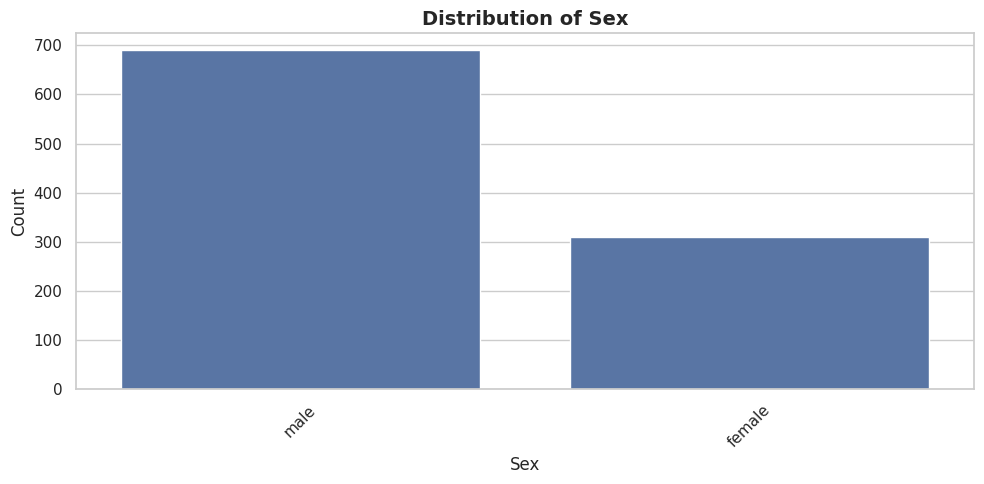

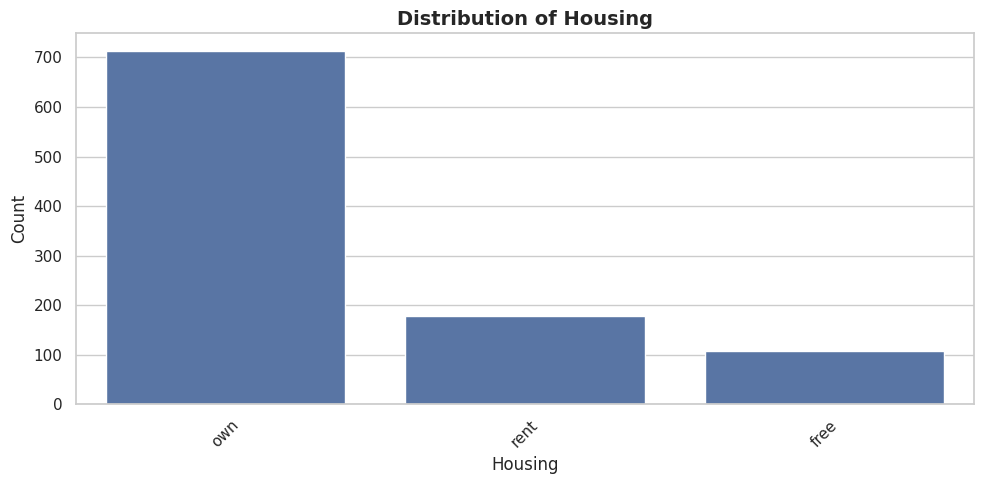

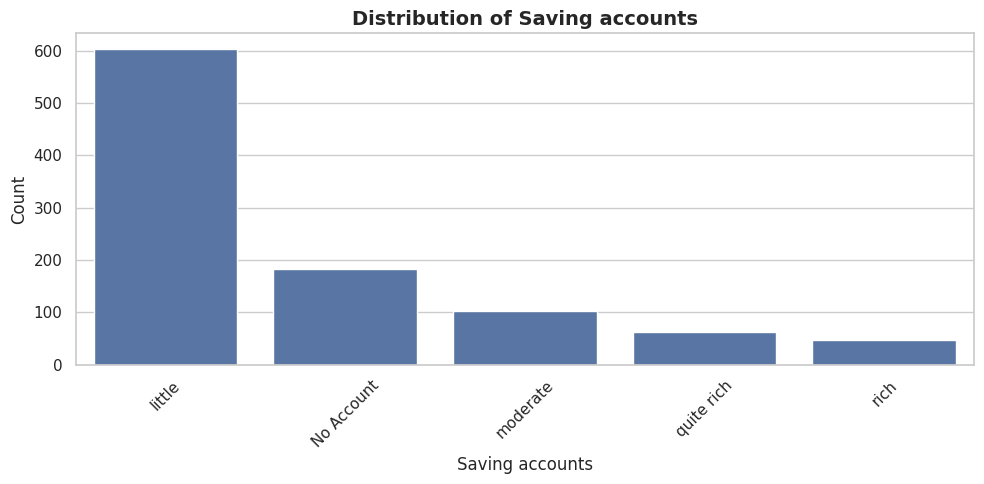

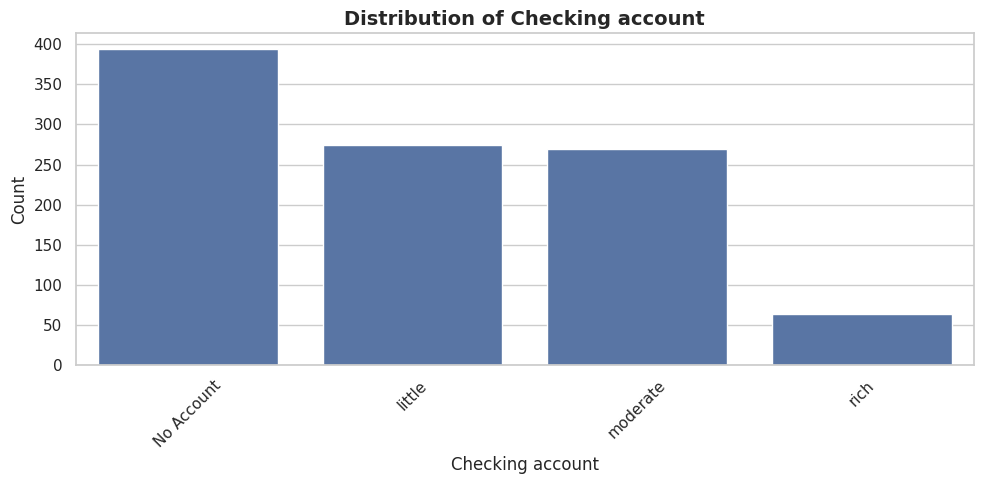

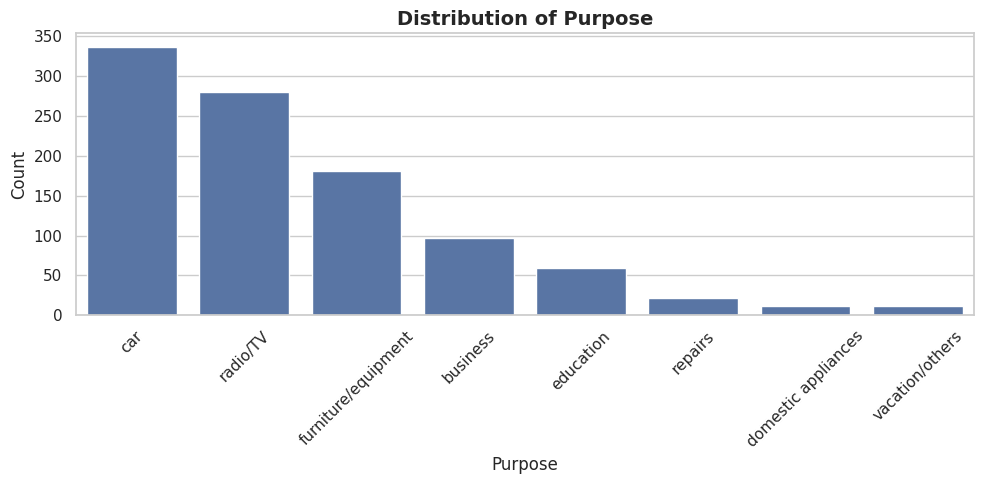

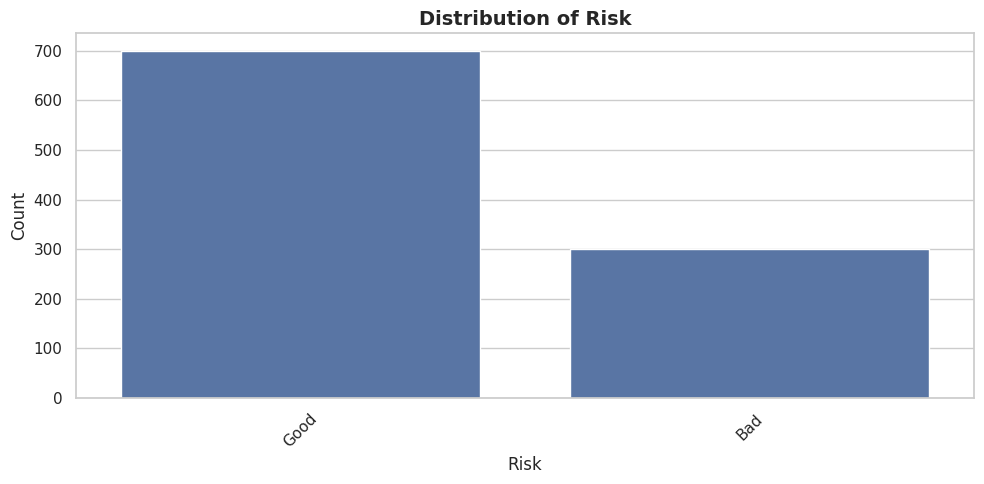

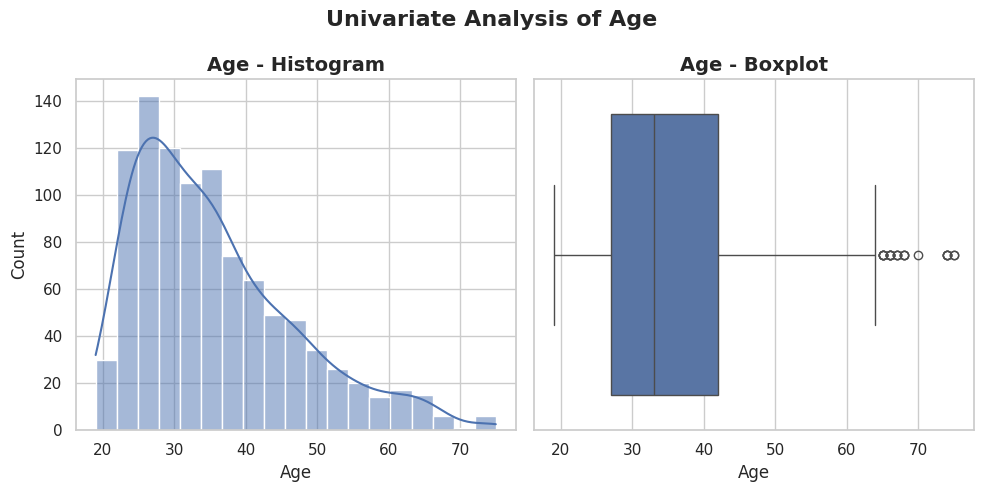

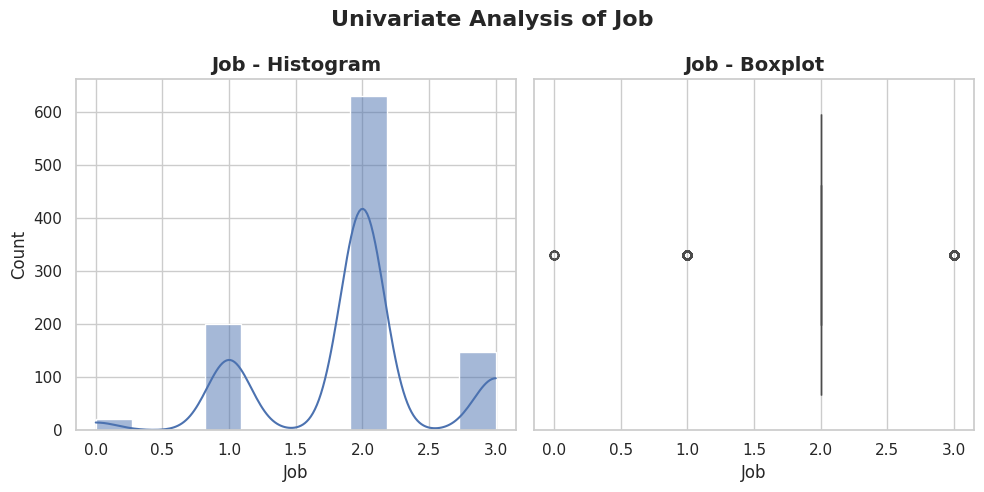

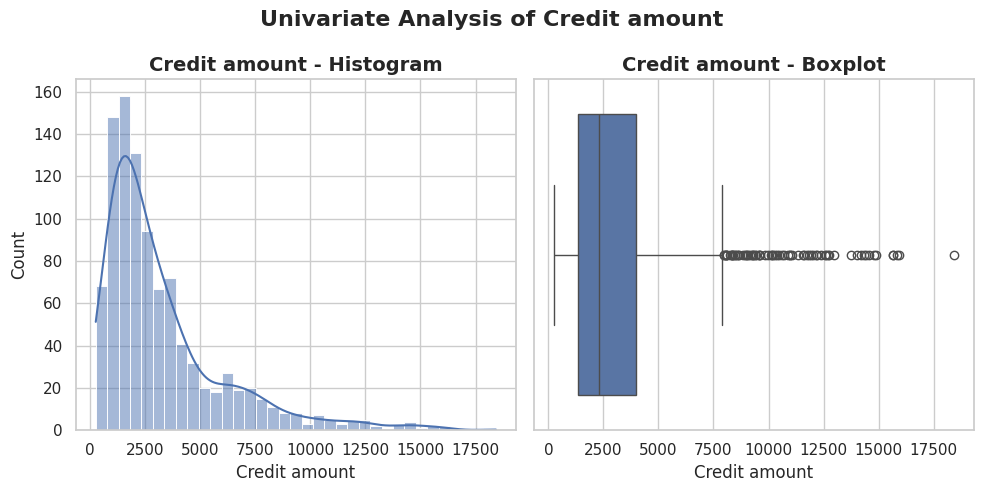

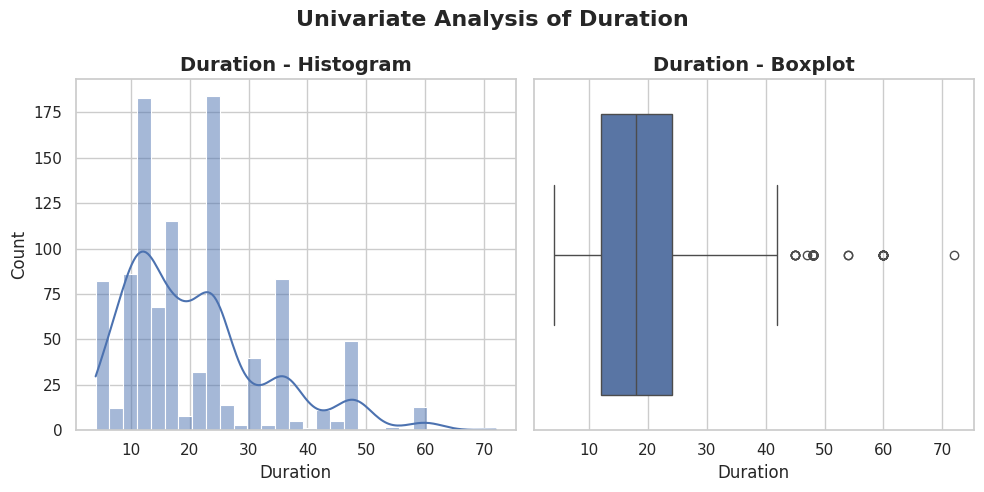

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Styling (premium look) ---
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# --- Separate columns ---
cat_cols = df.select_dtypes(include=['object', 'category']).columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# =========================
# 📊 CATEGORICAL VARIABLES
# =========================
for col in cat_cols:
    fig, ax = plt.subplots()

    order = df[col].value_counts().index

    sns.countplot(data=df, x=col, order=order, ax=ax)

    ax.set_title(f'Distribution of {col}', weight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


# =========================
# 📈 NUMERICAL VARIABLES
# =========================
for col in num_cols:
    fig, axes = plt.subplots(1, 2)

    # Histogram
    sns.histplot(df[col], kde=True, ax=axes[0])
    axes[0].set_title(f'{col} - Histogram', weight='bold')
    axes[0].set_xlabel(col)

    # Boxplot
    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title(f'{col} - Boxplot', weight='bold')
    axes[1].set_xlabel(col)

    # overall title
    fig.suptitle(f'Univariate Analysis of {col}', fontsize=16, weight='bold')

    plt.tight_layout()
    plt.show()

In [ ]:
skewness = df[num_cols].skew().sort_values(ascending=False)

print(skewness)

Credit amount    1.949628
Duration         1.094184
Age              1.020739
Job             -0.374295
dtype: float64


In [ ]:
skewed_cols = ['Credit amount', 'Duration', 'Age']

for col in skewed_cols:
    # Step 1: Fix skewness
    df[col] = np.log1p(df[col])

    # Step 2: Cap outliers
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

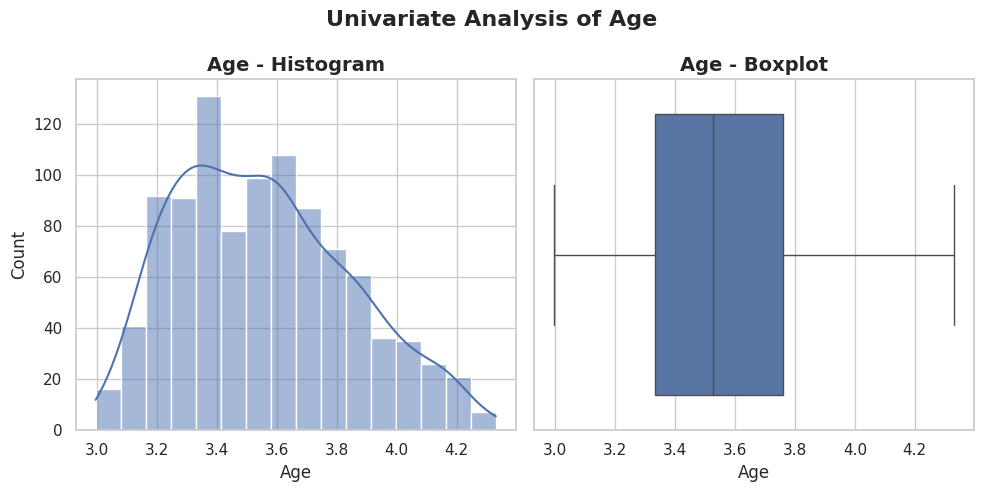

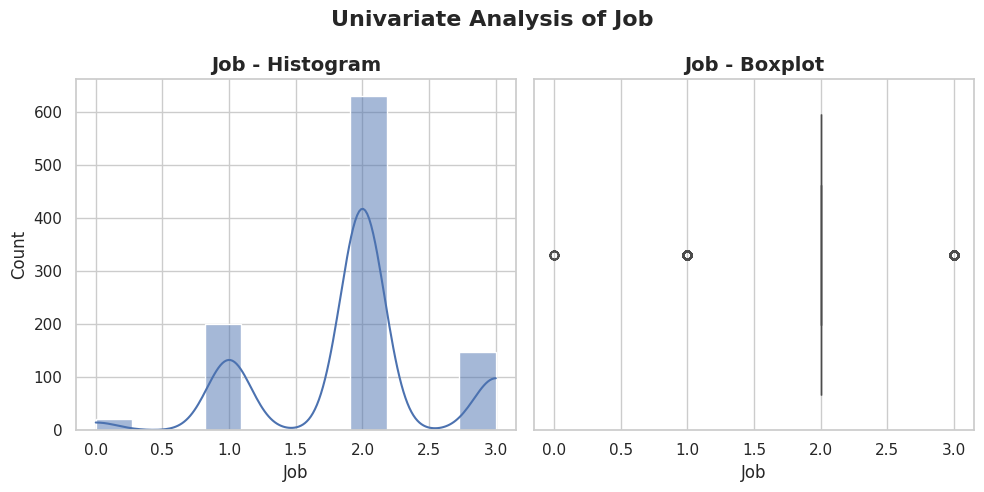

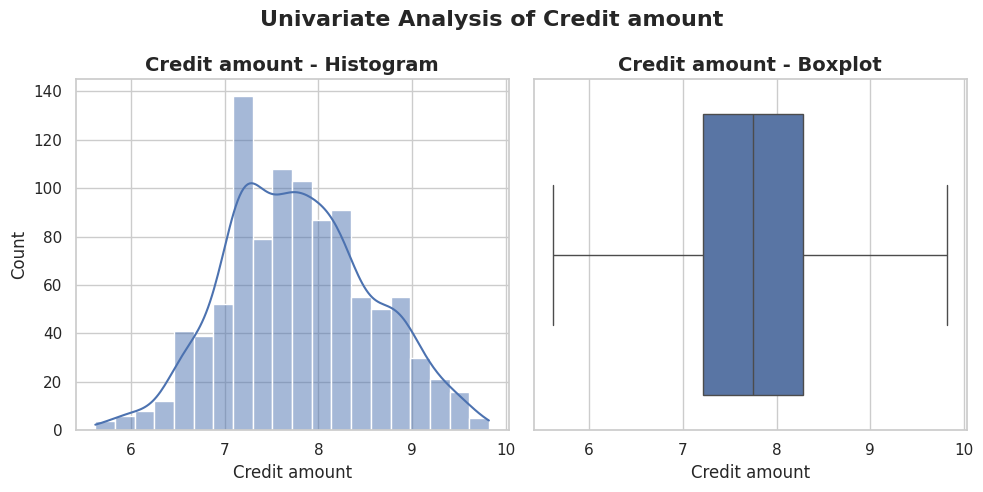

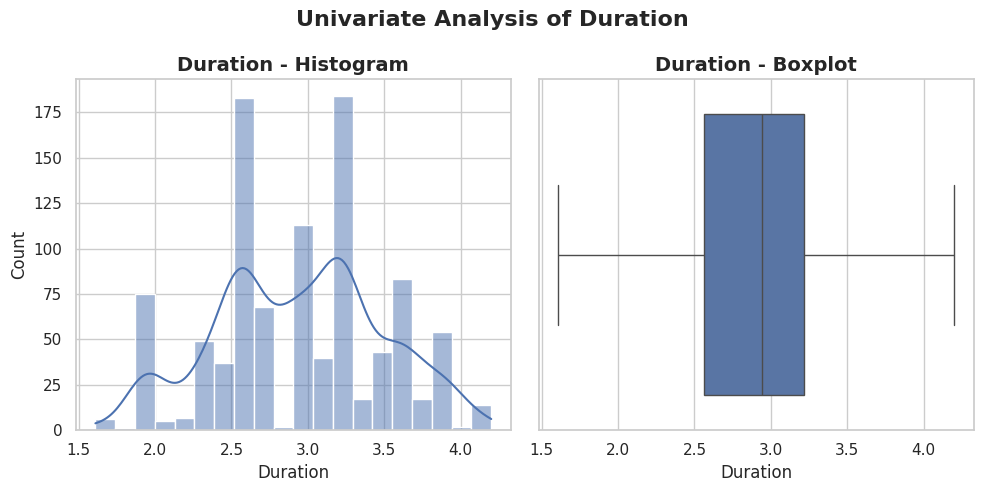

In [ ]:
# --- Styling (premium look) ---
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# =========================
# 📈 NUMERICAL VARIABLES
# =========================
for col in num_cols:
    fig, axes = plt.subplots(1, 2)

    # Histogram
    sns.histplot(df[col], kde=True, ax=axes[0])
    axes[0].set_title(f'{col} - Histogram', weight='bold')
    axes[0].set_xlabel(col)

    # Boxplot
    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title(f'{col} - Boxplot', weight='bold')
    axes[1].set_xlabel(col)

    # overall title
    fig.suptitle(f'Univariate Analysis of {col}', fontsize=16, weight='bold')

    plt.tight_layout()
    plt.show()

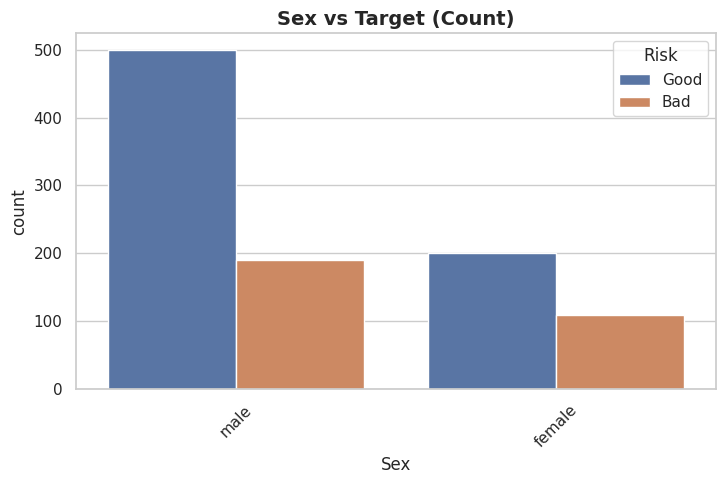

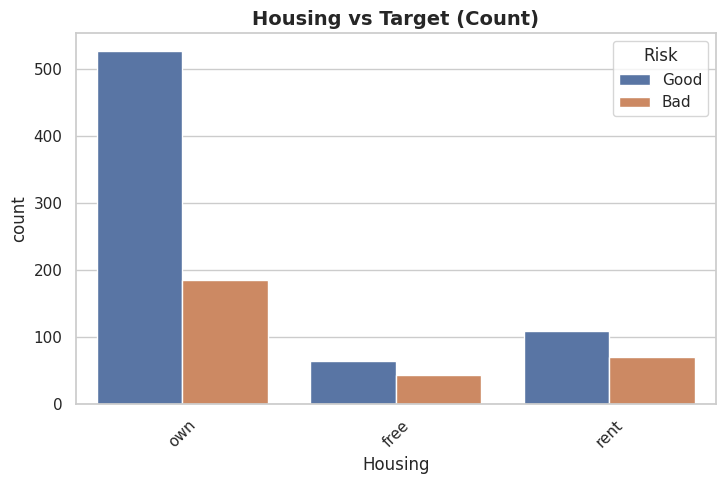

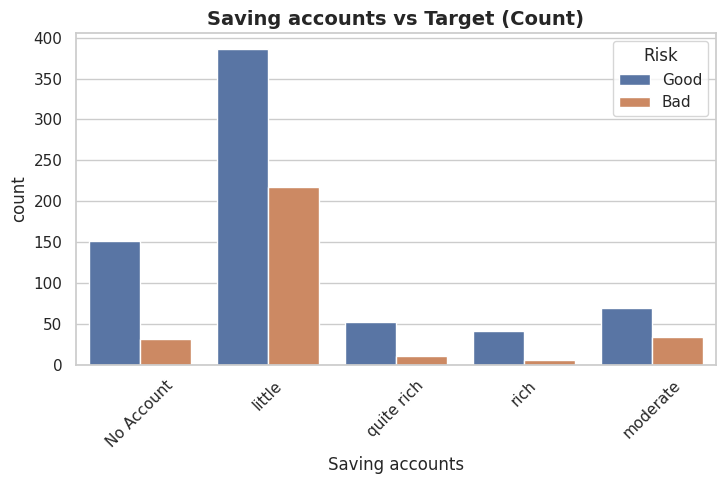

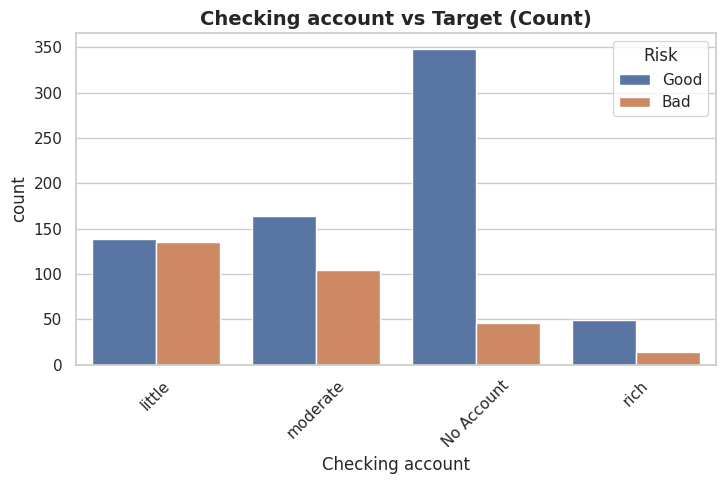

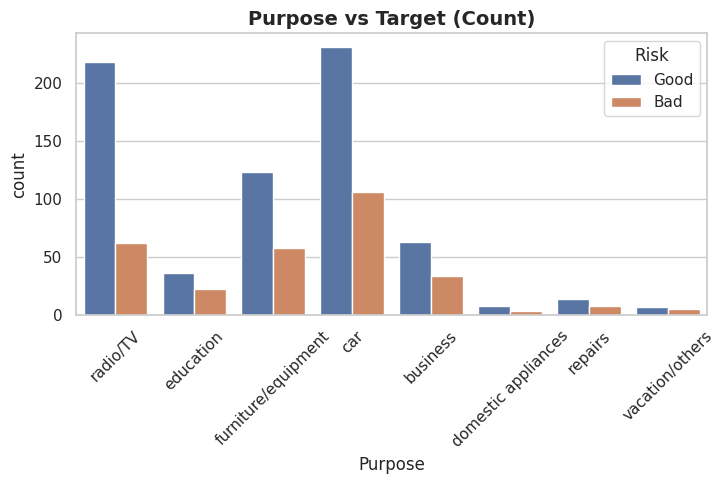

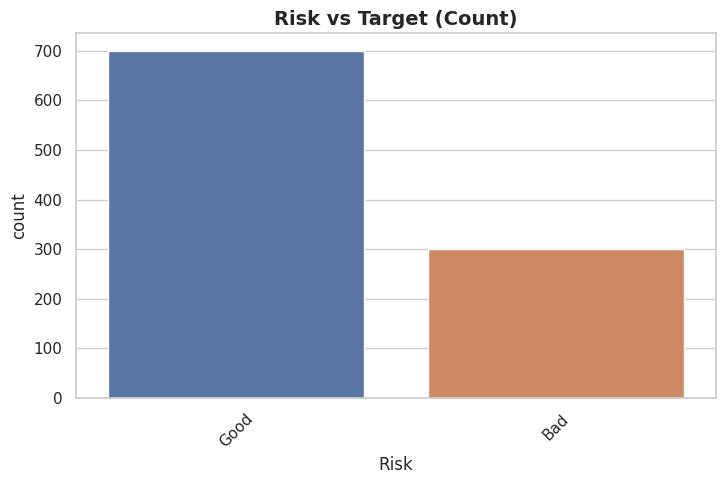

In [ ]:
for col in cat_cols:
    plt.figure(figsize=(14,5))

    # Count plot
    plt.subplot(1,2,1)
    sns.countplot(data=df, x=col, hue='Risk') # Changed hue='target' to hue='Risk'
    plt.title(f'{col} vs Target (Count)', weight='bold')
    plt.xticks(rotation=45)



    plt.tight_layout()
    plt.show()

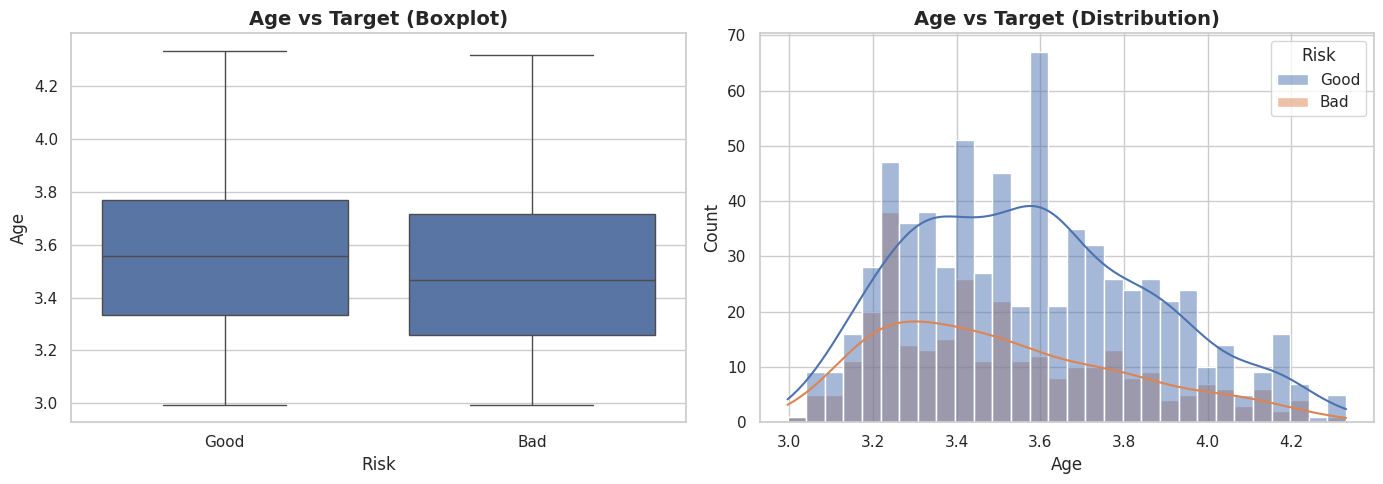

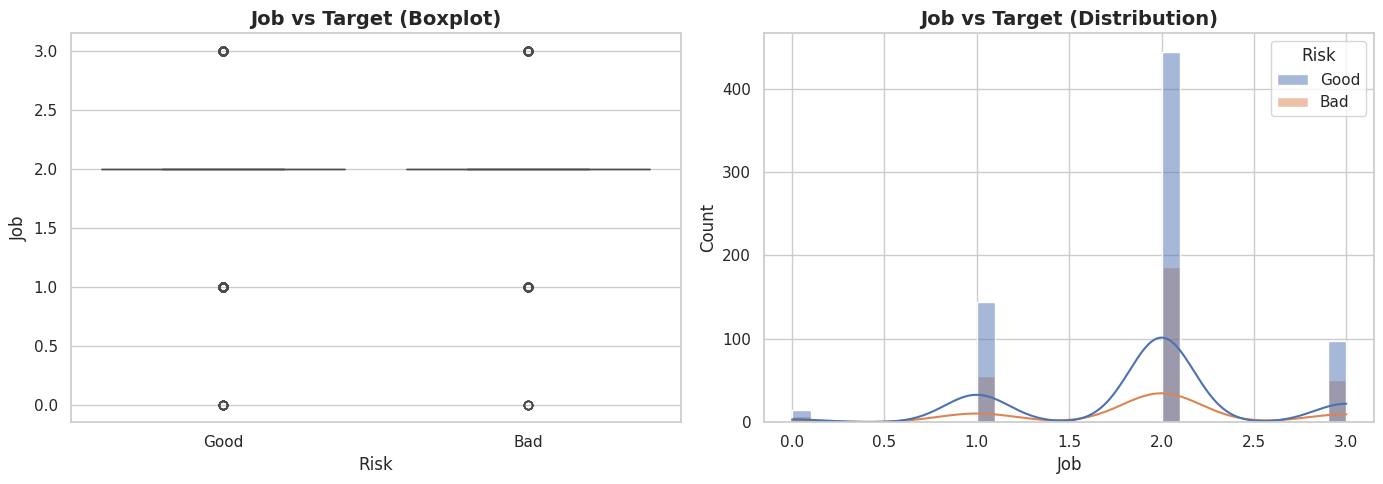

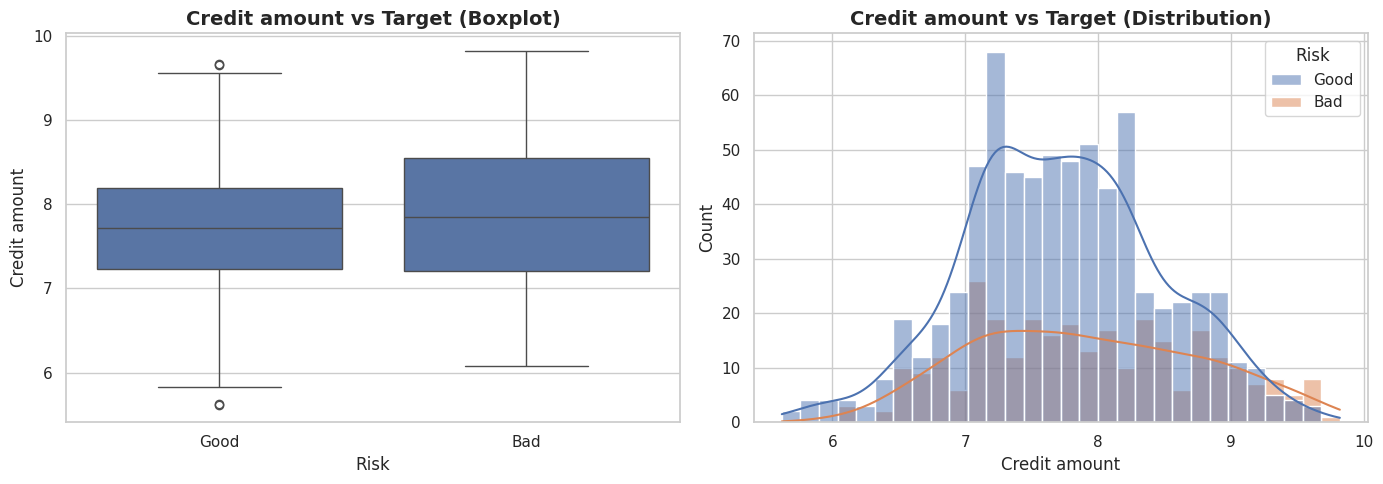

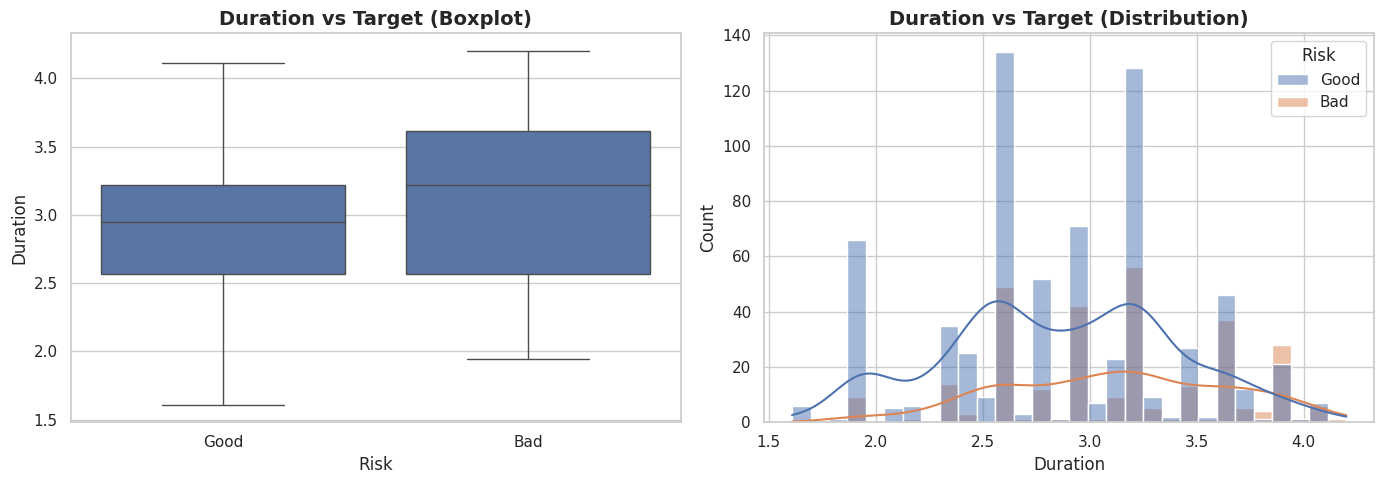

In [ ]:
for col in num_cols:
    plt.figure(figsize=(14,5))

    # Boxplot
    plt.subplot(1,2,1)
    sns.boxplot(data=df, x='Risk', y=col)
    plt.title(f'{col} vs Target (Boxplot)', weight='bold')

    # Distribution
    plt.subplot(1,2,2)
    sns.histplot(data=df, x=col, hue='Risk', kde=True, bins=30)
    plt.title(f'{col} vs Target (Distribution)', weight='bold')

    plt.tight_layout()
    plt.show()

In [ ]:
df.groupby('Risk')[num_cols].mean()

,Age,Job,Credit amount,Duration
Risk,,,,
Bad,3.508981,1.936667,7.919093,3.120223
Good,3.574107,1.890000,7.733728,2.863977


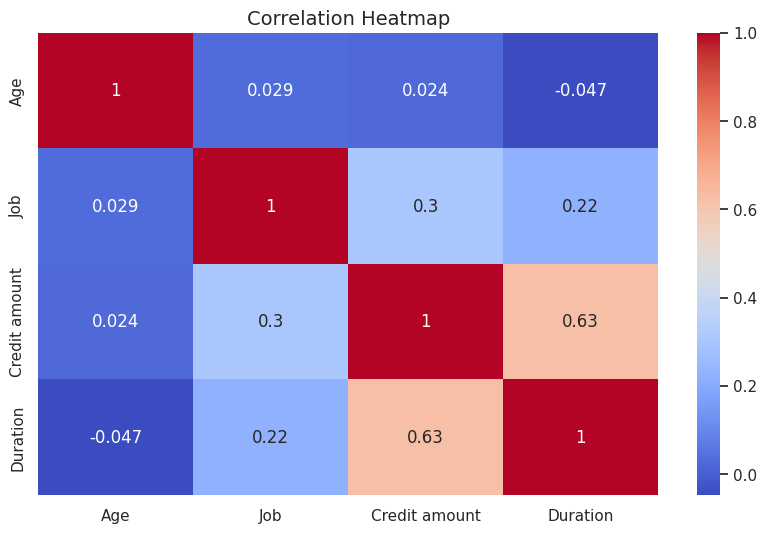

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
df_credit = df.copy()

In [ ]:
df_credit.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,4.219508,male,2,own,No Account,little,7.064759,1.945910,radio/TV,Good
1,3.135494,female,2,own,little,moderate,8.691483,3.891820,radio/TV,Bad
2,3.912023,male,1,own,little,No Account,7.648263,2.564949,education,Good
3,3.828641,male,2,free,little,little,8.972464,3.761200,furniture/equipment,Good
4,3.988984,male,2,free,little,little,8.491055,3.218876,car,Bad


In [ ]:
df_credit['Risk'] = df_credit['Risk'].map({'Good': 0, 'Bad': 1})

In [ ]:
df_credit.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,4.219508,male,2,own,No Account,little,7.064759,1.945910,radio/TV,0
1,3.135494,female,2,own,little,moderate,8.691483,3.891820,radio/TV,1
2,3.912023,male,1,own,little,No Account,7.648263,2.564949,education,0
3,3.828641,male,2,free,little,little,8.972464,3.761200,furniture/equipment,0
4,3.988984,male,2,free,little,little,8.491055,3.218876,car,1


In [ ]:
df_credit.describe()

,Age,Job,Credit amount,Duration,Risk
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,3.554569,1.904000,7.789337,2.940851,0.300000
std,0.291418,0.653614,0.775807,0.546160,0.458487
min,2.995732,0.000000,5.619010,1.609438,0.000000
25%,3.332205,2.000000,7.220008,2.564949,0.000000
50%,3.526361,2.000000,7.749538,2.944439,0.000000
75%,3.761200,2.000000,8.287340,3.218876,1.000000
max,4.330733,3.000000,9.821464,4.199766,1.000000


In [ ]:
cat_cols = df_credit.select_dtypes(include=['object', 'category']).columns

In [ ]:
df_credit = pd.get_dummies(df_credit, columns=cat_cols, drop_first=True)

In [ ]:
df_credit

,Age,Job,Credit amount,Duration,Risk,Sex_male,Housing_own,Housing_rent,Saving accounts_little,Saving accounts_moderate,...,Checking account_little,Checking account_moderate,Checking account_rich,Purpose_car,Purpose_domestic appliances,Purpose_education,Purpose_furniture/equipment,Purpose_radio/TV,Purpose_repairs,Purpose_vacation/others
0,4.219508,2,7.064759,1.945910,0,True,True,False,False,False,...,True,False,False,False,False,False,False,True,False,False
1,3.135494,2,8.691483,3.891820,1,False,True,False,True,False,...,False,True,False,False,False,False,False,True,False,False
2,3.912023,1,7.648263,2.564949,0,True,True,False,True,False,...,False,False,False,False,False,True,False,False,False,False
3,3.828641,2,8.972464,3.761200,0,True,False,False,True,False,...,True,False,False,False,False,False,True,False,False,False
4,3.988984,2,8.491055,3.218876,1,True,False,False,True,False,...,True,False,False,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,3.465736,1,7.459915,2.564949,0,False,True,False,True,False,...,False,False,False,False,False,False,True,False,False,False
996,3.713572,3,8.257904,3.433987,0,True,True,False,True,False,...,True,False,False,True,False,False,False,False,False,False
997,3.663562,2,6.690842,2.564949,0,True,True,False,True,False,...,False,False,False,False,False,False,False,True,False,False
998,3.178054,2,7.520776,3.828641,1,True,False,False,True,False,...,True,False,False,False,False,False,False,True,False,False


In [ ]:
from sklearn.model_selection import train_test_split

X = df_credit.drop('Risk', axis=1)
y = df_credit['Risk']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((800, 21), (200, 21), (800,), (200,))

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

# Apply ONLY on training data
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

In [ ]:
X_train_scaled.shape, X_test_scaled.shape, y_train_smote.shape, y_test.shape

((1120, 21), (200, 21), (1120,), (200,))

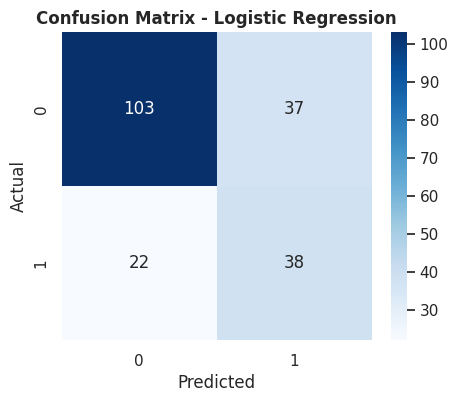

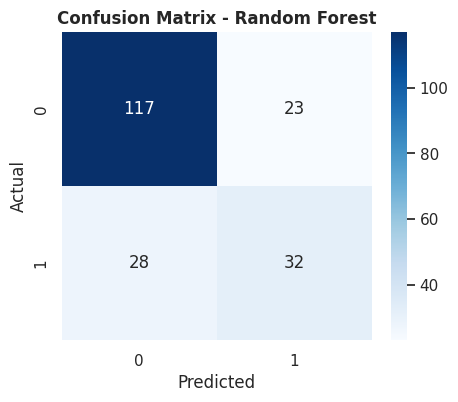

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[10:38:25] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.




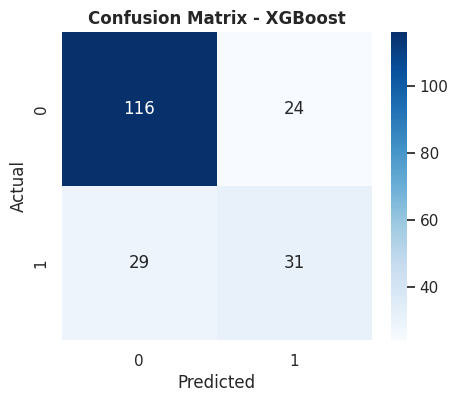


🔥 Model Comparison Results:

                 Model  Train Accuracy  Test Accuracy  Precision    Recall  \
1        Random Forest        1.000000          0.745   0.581818  0.533333   
0  Logistic Regression        0.761607          0.705   0.506667  0.633333   
2              XGBoost        1.000000          0.735   0.563636  0.516667   

   F1 Score   ROC-AUC  
1  0.556522  0.759405  
0  0.562963  0.736548  
2  0.539130  0.730357  


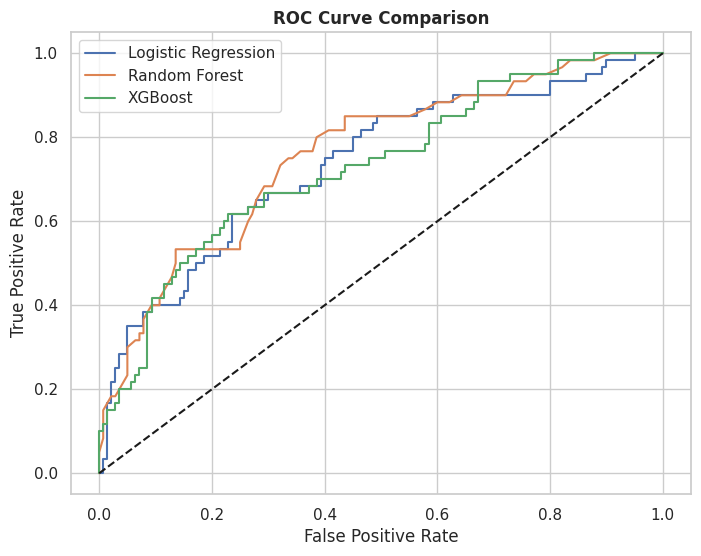

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve
)

sns.set_theme(style="whitegrid")

# -----------------------------
# 📌 Models
# -----------------------------
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

results = []
roc_data = {}

# -----------------------------
# 🚀 Train & Evaluate
# -----------------------------
for name, model in models.items():

    # Train
    model.fit(X_train_scaled, y_train_smote)

    # Predictions
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)

    y_test_prob = model.predict_proba(X_test_scaled)[:, 1]

    # Metrics
    train_acc = accuracy_score(y_train_smote, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    precision = precision_score(y_test, y_test_pred)
    recall = recall_score(y_test, y_test_pred)
    f1 = f1_score(y_test, y_test_pred)
    roc_auc = roc_auc_score(y_test, y_test_prob)

    # Store results
    results.append({
        "Model": name,
        "Train Accuracy": train_acc,
        "Test Accuracy": test_acc,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    })

    # ROC curve data
    fpr, tpr, _ = roc_curve(y_test, y_test_prob)
    roc_data[name] = (fpr, tpr)

    # -----------------------------
    # 📊 Confusion Matrix
    # -----------------------------
    cm = confusion_matrix(y_test, y_test_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {name}', weight='bold')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()


# -----------------------------
# 📋 Results Table
# -----------------------------
results_df = pd.DataFrame(results).sort_values(by="ROC-AUC", ascending=False)

print("\n🔥 Model Comparison Results:\n")
print(results_df)


# -----------------------------
# 📈 ROC Curve (All Models)
# -----------------------------
plt.figure(figsize=(8,6))

for name, (fpr, tpr) in roc_data.items():
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1], [0,1], 'k--')  # random line
plt.title("ROC Curve Comparison", weight='bold')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# -----------------------------
# 🔧 Parameter Grid
# -----------------------------
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'],  # supports both l1 & l2
    'class_weight': [None, 'balanced']
}

# -----------------------------
# 🚀 Grid Search
# -----------------------------
grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=5,
    scoring='recall',   # 🔥 IMPORTANT for your case
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train_scaled, y_train_smote)

# -----------------------------
# 📌 Best Model
# -----------------------------
best_model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters: {'C': 0.1, 'class_weight': None, 'penalty': 'l1', 'solver': 'liblinear'}


Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.72      0.78       140
           1       0.51      0.68      0.59        60

    accuracy                           0.71       200
   macro avg       0.68      0.70      0.68       200
weighted avg       0.74      0.71      0.72       200

ROC-AUC: 0.7528571428571428


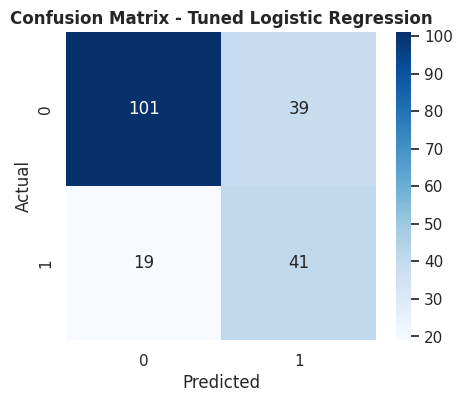

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

y_pred = best_model.predict(X_test_scaled)
y_prob = best_model.predict_proba(X_test_scaled)[:, 1]

print("Classification Report:\n", classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

# Confusion Matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Tuned Logistic Regression", weight='bold')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

# -----------------------------
# 🔧 Parameter Distribution
# -----------------------------
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 5, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False],
    'class_weight': [None, 'balanced']
}

# -----------------------------
# 🚀 Randomized Search
# -----------------------------
rf = RandomForestClassifier(random_state=42)

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=30,              # number of combinations to try
    cv=5,
    scoring='recall',       # 🔥 focus on catching bad customers
    n_jobs=-1,
    verbose=1,
    random_state=42
)

random_search.fit(X_train_scaled, y_train_smote)

# -----------------------------
# 📌 Best Model
# -----------------------------
best_rf = random_search.best_estimator_

print("Best Parameters:", random_search.best_params_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Parameters: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None, 'class_weight': None, 'bootstrap': False}


Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.86      0.83       140
           1       0.60      0.48      0.54        60

    accuracy                           0.75       200
   macro avg       0.70      0.67      0.68       200
weighted avg       0.74      0.75      0.74       200

ROC-AUC: 0.752797619047619


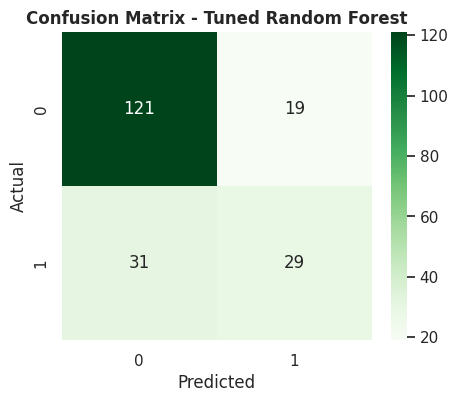

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

y_pred = best_rf.predict(X_test_scaled)
y_prob = best_rf.predict_proba(X_test_scaled)[:, 1]

print("Classification Report:\n", classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

# Confusion Matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - Tuned Random Forest", weight='bold')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

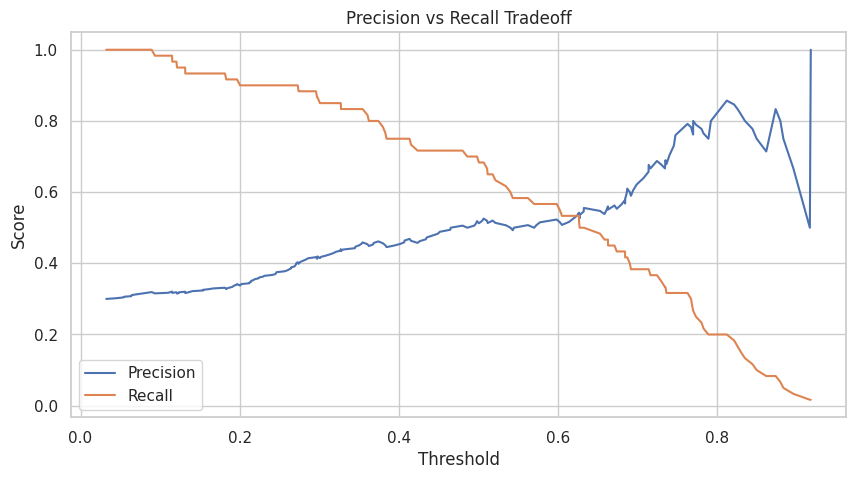

In [ ]:
from sklearn.metrics import precision_recall_curve

y_prob = best_model.predict_proba(X_test_scaled)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

# Plot
import matplotlib.pyplot as plt

plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.title("Precision vs Recall Tradeoff")
plt.show()

In [ ]:
y_pred_custom = (y_prob > 0.4).astype(int)

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       0.85      0.61      0.71       140
           1       0.45      0.75      0.57        60

    accuracy                           0.66       200
   macro avg       0.65      0.68      0.64       200
weighted avg       0.73      0.66      0.67       200



In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_recall_curve, precision_score, recall_score, f1_score

# Step 1: Get probabilities
y_prob = best_model.predict_proba(X_test_scaled)[:, 1]

# Step 2: Get thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

# Step 3: Build results table
results = []

for t in thresholds:
    y_pred = (y_prob >= t).astype(int)

    results.append({
        "threshold": t,
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)

# Step 4: Find best threshold using smart logic
max_f1 = results_df['f1'].max()

tolerance = 0.02  # allow small drop in F1

candidates = results_df[
    results_df['f1'] >= (max_f1 - tolerance)
]

best_row = candidates.sort_values(by='recall', ascending=False).iloc[0]

# Step 5: Final output
best_threshold = best_row['threshold']

print("🔥 Final Selected Threshold:", round(best_threshold, 3))
print("\nMetrics at this threshold:")
print(best_row)

# Step 6: Final predictions
y_pred_final = (y_prob >= best_threshold).astype(int)

🔥 Final Selected Threshold: 0.327

Metrics at this threshold:
threshold    0.326985
precision    0.435897
recall       0.850000
f1           0.576271
Name: 83, dtype: float64



--- Tuned Logistic Regression (with Optimal Threshold) ---

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.53      0.66       140
           1       0.44      0.85      0.58        60

    accuracy                           0.62       200
   macro avg       0.66      0.69      0.62       200
weighted avg       0.75      0.62      0.64       200



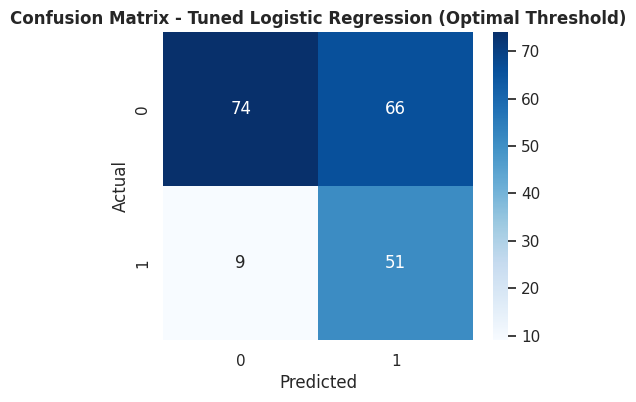

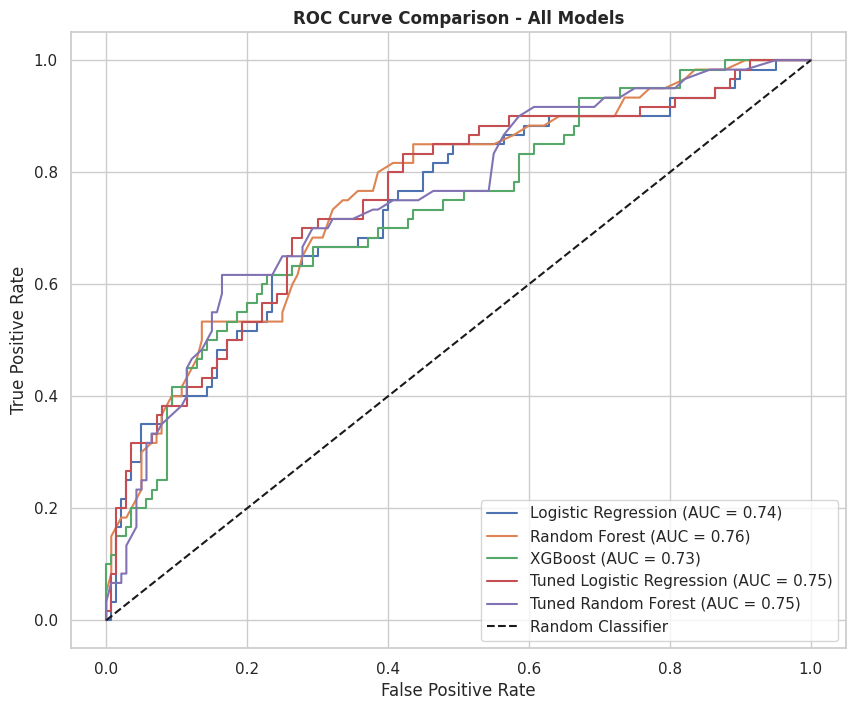

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, auc # Import auc

sns.set_theme(style="whitegrid")

# --- Final Classification Report and Confusion Matrix for Tuned Logistic Regression (with optimal threshold) ---
print("\n--- Tuned Logistic Regression (with Optimal Threshold) ---\n")
print("Classification Report:\n", classification_report(y_test, y_pred_final))

cm_tuned_lr_optimal = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(5,4))
sns.heatmap(cm_tuned_lr_optimal, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Tuned Logistic Regression (Optimal Threshold)", weight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# --- Prepare ROC data for all models (including tuned ones) ---
# Re-use existing roc_data from cell gL-ZU2EoWDHn, then add tuned models
# Make sure to run cell gL-ZU2EoWDHn to get the original roc_data if not already in kernel

# ROC data for Tuned Logistic Regression
y_prob_tuned_lr = best_model.predict_proba(X_test_scaled)[:, 1]
fpr_tuned_lr, tpr_tuned_lr, _ = roc_curve(y_test, y_prob_tuned_lr)

# ROC data for Tuned Random Forest
y_prob_tuned_rf = best_rf.predict_proba(X_test_scaled)[:, 1]
fpr_tuned_rf, tpr_tuned_rf, _ = roc_curve(y_test, y_prob_tuned_rf)

# Consolidate ROC data
final_roc_data = roc_data.copy() # Start with initial models
final_roc_data['Tuned Logistic Regression'] = (fpr_tuned_lr, tpr_tuned_lr)
final_roc_data['Tuned Random Forest'] = (fpr_tuned_rf, tpr_tuned_rf)

# --- ROC Curve Comparison (All Models) ---
plt.figure(figsize=(10,8))

for name, (fpr, tpr) in final_roc_data.items():
    # Use auc(fpr, tpr) instead of roc_auc_score(y_test, tpr) to calculate AUC from the curve data
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc(fpr, tpr):.2f})')

plt.plot([0,1], [0,1], 'k--', label='Random Classifier')  # Random line
plt.title("ROC Curve Comparison - All Models", weight='bold')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()